In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Charging the future: Electric vs Gas Powered Vehicles


In recent times, there has been a shift in the type of vehicles on the roads of America. The reason for this shift is due to the uncertain future of this world that comes with global warming. Since 1850, the combined land and ocean temperature has increased a total of 2 degrees Farhenheight according to the NOAA's 2023 annual climate report. The rate of warming is also about 3 times as fast per decade now than it was in 1982. This encouraged car companies to release hybrib and electric powered alternatives, and an uprise in purchase and use of these vehicles has been apparent in the 21st century. 

Text(0.5, 1.0, 'New Vehicle Fuel Type by Year')

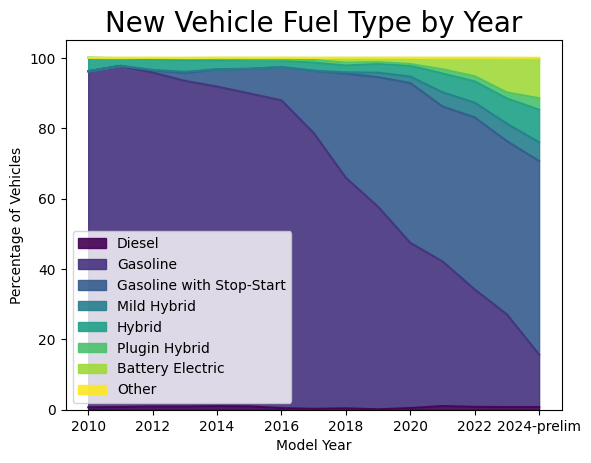

In [131]:
vehicle_trends = pd.read_csv("https://raw.githubusercontent.com/sanjnat26/final_report_dsci235/refs/heads/main/cleaner-technologies-and.csv")
vehicle_trends.set_index('Model Year', inplace=True)
vehicle_trends.plot(kind='area', stacked=True, colormap='viridis', alpha=0.9)

plt.ylabel("Percentage of Vehicles")
plt.title("New Vehicle Fuel Type by Year", fontsize=20)

The graph above is sourced from data from the United States Environmental Protection Agency's automotive trends report. In the graph above, we can see an apparent increase in the percentage of new hybrid and electric vehicles from 2010 until now. However, it seems to have only started ramping up around 2019-2020. Let's focus on the growth of electric vehicles.

In [132]:
electric_2019 = vehicle_trends.loc["2019", "Battery Electric"]
electric_2024 = vehicle_trends.loc["2024-prelim", "Battery Electric"]

growth = (electric_2024 - electric_2019)
growth

np.float64(10.190000000000001)

From 2019 to 2024 there has been a 10.19 percent increase in the number of new electric powered vehicles. Evidently, the United States believes that electric powered vehicles are much more efficient and environmentally friendly than gasoline powered vehicles. So, what is the real value of choosing to drive an electric powered vehicle over a gasoline powered one?

This next dataset reflects information on vehicle specifications, fuel consumption, and CO2 emissions in Canada. The first thing I want to look into is how the vehicle classification effects the CO2 emissions.  

In [133]:
co2Emissions_data = pd.read_csv("https://raw.githubusercontent.com/sanjnat26/final_report_dsci235/refs/heads/main/CO2%20Emissions_Canada.csv")
co2_class = co2Emissions_data.groupby('Vehicle Class')['CO2 Emissions(g/km)'].mean().reset_index()
co2_class = co2_class.sort_values(by='CO2 Emissions(g/km)', ascending=False)
co2_class

,Vehicle Class,CO2 Emissions(g/km)
15,VAN - PASSENGER,397.212121
14,VAN - CARGO,361.500000
12,SUV - STANDARD,304.836735
6,PICKUP TRUCK - STANDARD,301.513011
5,PICKUP TRUCK - SMALL,278.968553
13,TWO-SEATER,277.454348
1,FULL-SIZE,263.316119
4,MINIVAN,262.312500
10,SUBCOMPACT,246.448845
8,STATION WAGON - MID-SIZE,238.698113


The table above reflects the somewhat obvious -- the bigger the car is, the higher the CO2 emissions will be. I also want to see how the vehicles fuel type effects co2 emissions.

In [134]:
co2_fuels = co2Emissions_data.groupby('Fuel Type')['CO2 Emissions(g/km)'].mean().reset_index()
co2_fuels.sort_values(by='CO2 Emissions(g/km)', ascending=False)

,Fuel Type,CO2 Emissions(g/km)
1,E,275.091892
4,Z,266.043410
0,D,237.548571
3,X,235.119329
2,N,213.000000


# Fuel Type Key:
E - Ethanol <br>
Z - Premium Gasoline <br>
D - Diesel <br>
X - Regular Gasoline <br>
N - Natural Gasoline

Clearly, we can see that the fuel type creates significant differences in CO2 emissions. Let's focus on mid-size vehicles and vans for the moment.

In [135]:
mid_size = co2Emissions_data[(co2Emissions_data['Vehicle Class'] == 'MID-SIZE')]
fuel_counts = mid_size['Fuel Type'].value_counts()
fuel_counts.idxmax()

'X'

In [136]:
vans = co2Emissions_data[(co2Emissions_data['Vehicle Class'] == 'VAN - CARGO') | (co2Emissions_data['Vehicle Class'] == 'VAN - PASSENGER')]
van_fuel_counts = vans['Fuel Type'].value_counts()
van_fuel_counts.idxmax()

'X'

In [137]:
van_fuel_counts.idxmin()

'E'

Above, I have found the most used fuel type for a mid size car and a van. Since they are both regular gasoline, lets assume that the majority of vehicle classifications will use regular gasoline most of the time. Also, the vehicles classification clearly has a larger effect on the overall co2 emissions because the least used fuel type for vans was ethonol, which is linked with high co2 emissions.

Now, lets dig into some data about electric vehicles sourced from the electric vehicle database.

Text(0.5, 1.0, 'Efficiency of Electric Cars by Drive Type')

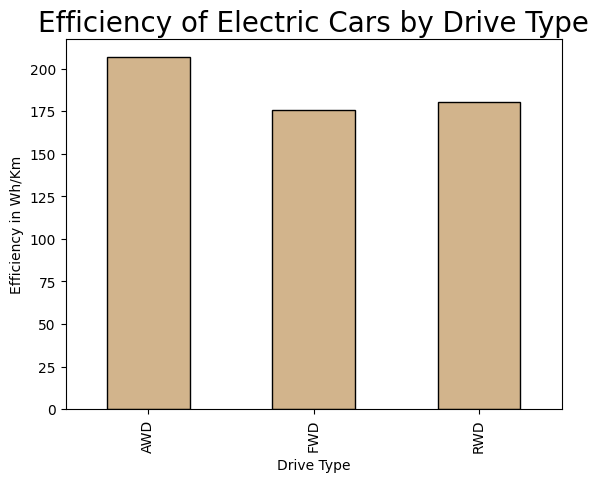

In [138]:
electric_cars = pd.read_csv("https://raw.githubusercontent.com/sanjnat26/final_report_dsci235/refs/heads/main/ElectricCarData_Clean.csv")
electric_by_efficiency = electric_cars.groupby('PowerTrain')['Efficiency_WhKm'].mean()
electric_by_efficiency.plot(kind='bar', color='tan', edgecolor='black')
plt.ylabel('Efficiency in Wh/Km')
plt.xlabel('Drive Type')
plt.title('Efficiency of Electric Cars by Drive Type', fontsize=20)

The graph above reflects that all wheel drive cars are less efficient than those that are front wheel or rear wheel drive. To interpret Wh/Km in CO2 emissions, there are multiple calculations that have to be done.

The average CO2 emissions per kWh in the US is 0.81 pounds.

In [139]:
0.81 * 453.592

367.40952

Converted to grams, this value is 367.40952. To convert Wh/Km to CO2 emissions in g/km we have to multiply to value of Wh/Km by 1/1000 and by 367.40952. Lets add this column in our electric vehicle dataset.

In [140]:
electric_cars['CO2 Emissions(g/km)'] = electric_cars['Efficiency_WhKm'] * (367.4095/1000)
electric_cars.head()

,Brand,Model,AccelSec,TopSpeed_KmH,Range_Km,Efficiency_WhKm,FastCharge_KmH,RapidCharge,PowerTrain,PlugType,BodyStyle,Segment,Seats,PriceEuro,CO2 Emissions(g/km)
0,Tesla,Model 3 Long Range Dual Motor,4.6,233,450,161,940,Yes,AWD,Type 2 CCS,Sedan,D,5,55480,59.152929
1,Volkswagen,ID.3 Pure,10.0,160,270,167,250,Yes,RWD,Type 2 CCS,Hatchback,C,5,30000,61.357386
2,Polestar,2,4.7,210,400,181,620,Yes,AWD,Type 2 CCS,Liftback,D,5,56440,66.501120
3,BMW,iX3,6.8,180,360,206,560,Yes,RWD,Type 2 CCS,SUV,D,5,68040,75.686357
4,Honda,e,9.5,145,170,168,190,Yes,RWD,Type 2 CCS,Hatchback,B,4,32997,61.724796


With that column added to the electric cars dataset, lets merge the two datasets for the the three columns: brand, type, and co2 emissions.

In [141]:
electric_cars['Type'] = 'Electric'
co2Emissions_data['Type'] = 'non-EV'
co2Emissions_data.rename(columns={"Make": "Brand"}, inplace=True)
gas_df = co2Emissions_data[['Brand', 'Type', 'CO2 Emissions(g/km)']]
ev_df = electric_cars[['Brand', 'Type', 'CO2 Emissions(g/km)']]
merged_data = pd.concat([ev_df, gas_df], ignore_index=True)
merged_data

,Brand,Type,CO2 Emissions(g/km)
0,Tesla,Electric,59.152929
1,Volkswagen,Electric,61.357386
2,Polestar,Electric,66.501120
3,BMW,Electric,75.686357
4,Honda,Electric,61.724796
...,...,...,...
7483,VOLVO,non-EV,219.000000
7484,VOLVO,non-EV,232.000000
7485,VOLVO,non-EV,240.000000
7486,VOLVO,non-EV,232.000000


Let's find the smallest co2 emmissions from the non electric cars in the dataset.

In [142]:
co2Emissions_data['CO2 Emissions(g/km)'].min()

96

Now lets find the largest co2 emissions from the electric cars in the dataset.

In [143]:
electric_cars['CO2 Emissions(g/km)'].max()

100.3027935

From this we can see that the benefits of an electric car on the environment are substanstial. The largest co2 emissions in g/km from an electric car is only 4 more than the smallest co2 emissions in g/km from a non-ev vehicle. 

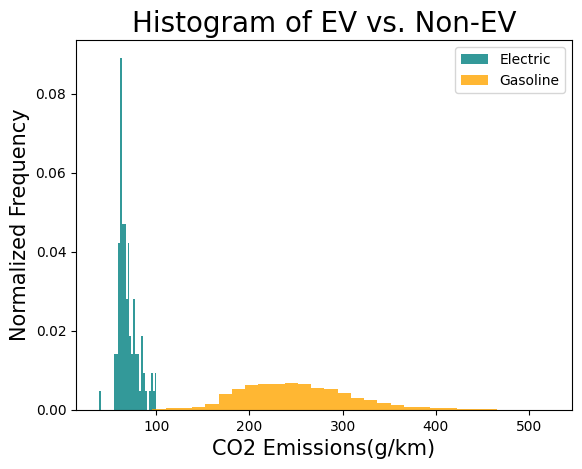

In [144]:
merged_data[merged_data['Type'] == 'Electric']['CO2 Emissions(g/km)'].plot(kind='hist', density=True, alpha=0.8, bins=30, label='Electric', color='teal')
merged_data[merged_data['Type'] == 'non-EV']['CO2 Emissions(g/km)'].plot(kind='hist', density=True, alpha=0.8, bins=30, label='Gasoline', color='orange')

plt.ylabel("Normalized Frequency", fontsize=15)
plt.xlabel("CO2 Emissions(g/km)", fontsize=15)
plt.title("Histogram of EV vs. Non-EV", fontsize=20)
plt.legend()

# Conclusion
The analysis of CO2 emissions between electric and non-electric vehicles, as illustrated in the histogram above, clearly demonstrates a distinct separation in emissions levels, with minimal overlap between the two vehicle types. This stark contrast highlights that, regardless of a gas-powered vehicle's classification or fuel type, it will inevitably emit significantly more CO2 than an electric vehicle. <bg>
<bg>
While electric vehicles are not entirely free from emissions, the overall environmental impact is far less detrimental than that of gasoline-powered vehicles. In a world where global warming and climate change are urgent concerns, switching to an electric vehicle presents a meaningful way to reduce one's carbon footprint. <bg>
<bg>
If you are in the market for a new car, I would strongly recommend considering an electric vehicle. Electric vehicles represent a crucial step towards a cleaner future.